# Advanced machine learning coursework
## Task 1:

In [1]:
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
import warnings
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import datetime as dt

from task_1_data_prep import Country, CountryList, create_impute
from task_2_Kmeans import Autoencoder
from task_3_MLP import train_MLP, reTrain_MLP,test_MLP
from task_4_forcast import MAPELoss, LSTMModel, CNNLSTMModel, PositionalEncoding, TransformerModel

In [2]:
"""original data initalisation
It is important to have a copy of the countries before any data augementation so that
we can access the original version
"""
original_data = pd.read_csv("world_bank_data_dev.csv") #this stores the original data without any altering
original_data["date"] = pd.to_datetime(original_data["date"]) #changes the date values into datetime
original_countries = CountryList() #creates the CountryList class
original_countries.load_dataset(original_data) #seperates the dataset by country, adds the country's data into a dataframe as a class attribute
original_countries.create_sliding_windows() #creates the sliding window for each country 

In [3]:
"""import imputed csv file"""

data = pd.read_csv("world_bank_data_imputed.csv")
data["date"] = pd.to_datetime(data["date"]) #changes the date values into datetime

#scaling dataset
numeric_columns = data.select_dtypes(include=["float64"]).columns #selects the feature columns
scaler = MinMaxScaler() #initalize scaler
data[numeric_columns] = scaler.fit_transform(data.select_dtypes(include=["float64"])) #scales the data

countries = CountryList() #creates the CountryList class
countries.load_dataset(data) #seperates the dataset by country, adds the country's data into a dataframe as a class attribute
countries.create_sliding_windows() #creates the sliding window for each country 
unique_countries = data['country'].unique()

numeric_columns = data.select_dtypes(include=["float64"]).columns #selects the feature column indexes
original_scaled_data = data.where(~original_data.isna(), other=np.nan) #removes filled data from scaled dataframe
original_scaled_countries = CountryList() #creates the CountryList class
original_scaled_countries.load_dataset(original_scaled_data) #seperates the dataset by country, adds the country's data into a dataframe as a class attribute
original_scaled_countries.create_sliding_windows()


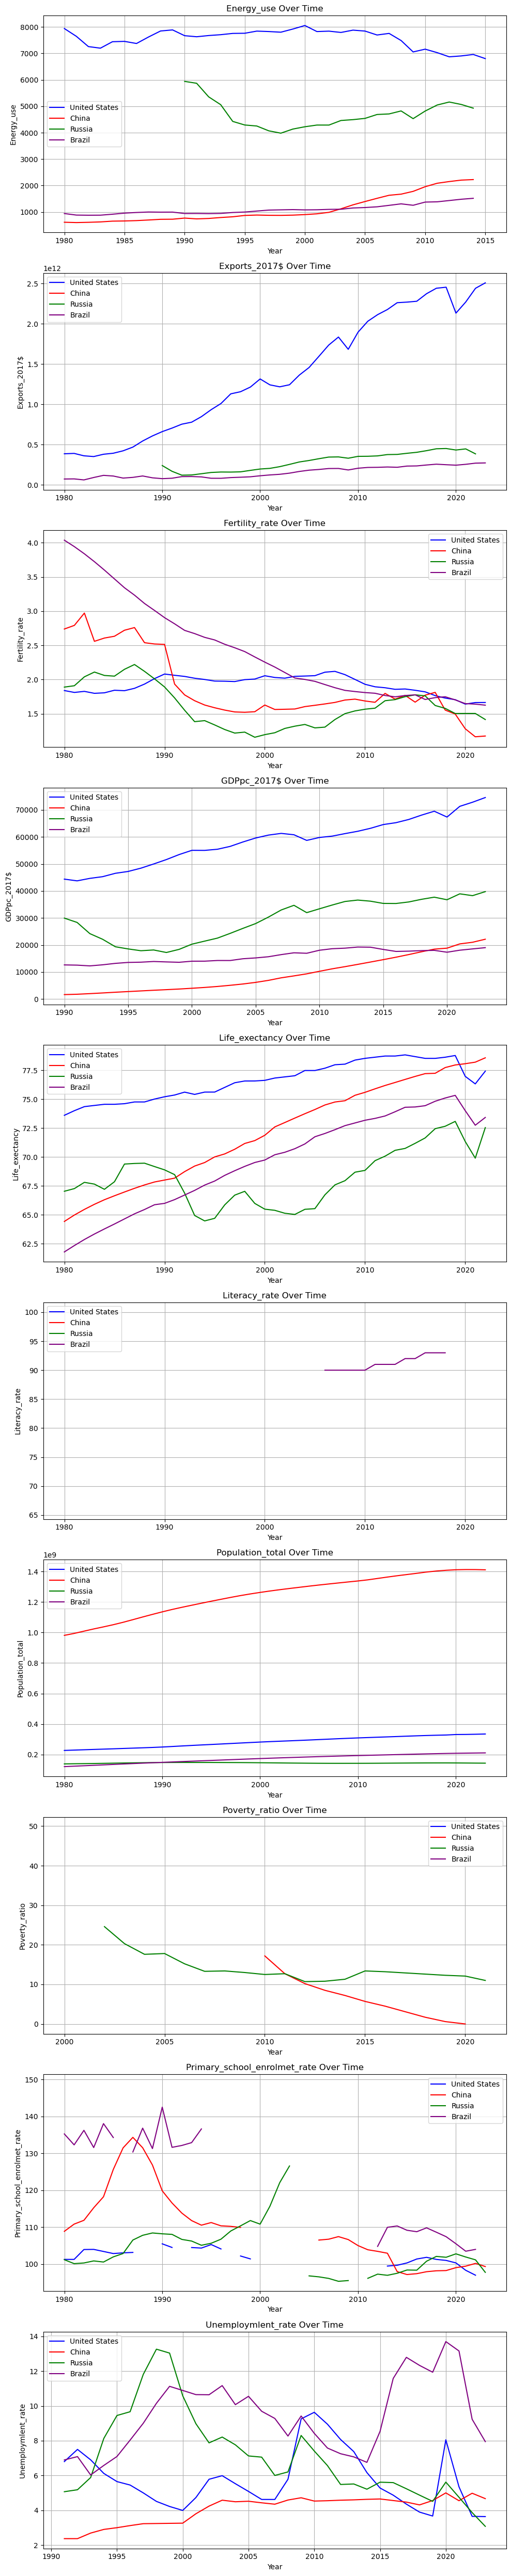

In [4]:
"""This gets the dataframe for each country for exploratory stats"""
usa_data = original_countries.get_country_data("United States").get_df() #gets the time series data for usa
china_data = original_countries.get_country_data("China").get_df() #gets the time series data for china
russia_data = original_countries.get_country_data("Russian Federation").get_df() #gets the time series data for russia
brazil_data = original_countries.get_country_data("Brazil").get_df() #gets the time series data for brazil

#preps data to be plotted
indicators = usa_data.columns.difference(["country", "date", "year"]) #removes date and country from headers

countries_data = {
    "United States": usa_data,
    "China": china_data,
    "Russia": russia_data,
    "Brazil": brazil_data
}

colors = {
    "United States": "blue",
    "China": "red",
    "Russia": "green",
    "Brazil": "purple"
}

#create plots for each indicator
fig, axes = plt.subplots(len(indicators), 1, figsize=(10, 50))

for i, indicator in enumerate(indicators):
    ax = axes[i]  #select the correct plot
    for country, df in countries_data.items():
        df["year"] = df["date"].dt.year  #get only the year
        ax.plot(df["year"], df[indicator], label=country, color=colors[country])

    ax.set_title(f"{indicator} Over Time")
    ax.set_xlabel("Year")
    ax.set_ylabel(indicator)
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()   

## Task 2:

In [5]:
"""data aggregation by PCA"""
numeric_columns = data.select_dtypes(include=["float64"]).columns #selects the feature columns
countries.create_sliding_windows()
task_2_list = countries.get_list()

stats_list = []
pca_list = []
for country in task_2_list:
    stats_list = []
    for window in country.get_windows():
        datapoint = window[numeric_columns].mean(axis=0)
        stats_list.append(datapoint)
    stats_merge = pd.concat(stats_list,axis=1)
    pca = PCA(n_components=5)
    data_reduced = pca.fit_transform(stats_merge)
    data_reduced = data_reduced.flatten().reshape(-1,1)
    data_reduced = data_reduced.T
    pca_list.append(data_reduced)
    
pca_features = np.vstack(pca_list)
stat_features = pca_features

In [6]:
"""Autoencoder and Evaluation"""
X_train, X_test = train_test_split(stat_features, test_size=0.2, random_state=42)
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, X_train_tensor) # target is input
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize the model
input_size = X_train.shape[1]
latent_size = 10  # We want to reduce it to 2 values per country
model = Autoencoder(input_size, latent_size)

# Define the loss function and optimizer
criterion = nn.MSELoss()  # Use Mean Squared Error Loss for reconstruction
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model on the entire dataset
epochs = 100

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
train_losses = []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch_features, _ in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_features)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_features.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)    
    
model.eval()
with torch.no_grad():
    X_tensor = torch.FloatTensor(stat_features)
    latent_representations = model.encoder(X_tensor).numpy()

In [7]:
"""loads"""
if os.path.exists("latent_rep2.csv"):
    latent_frame = pd.read_csv("latent_rep2.csv")
    latent_representations = latent_frame.values
else:
    latent_frame = pd.DataFrame(latent_representations)
    latent_frame.to_csv("latent_rep2.csv", index = False) 

C:\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Silhouette Score: 0.4640455662061602


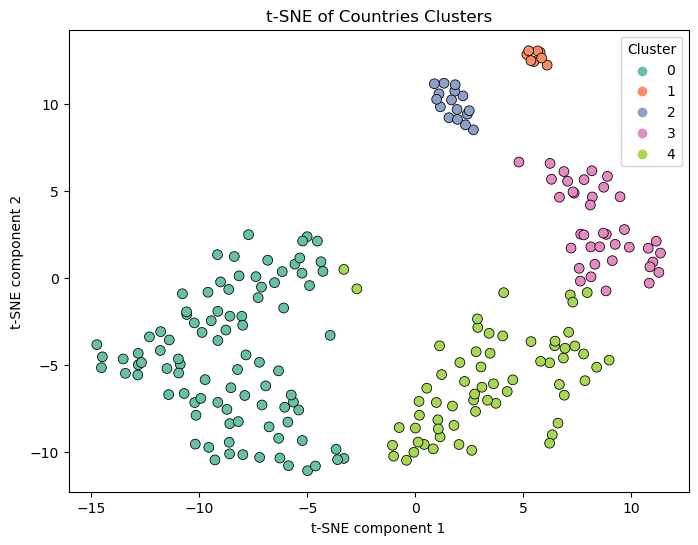

In [8]:
#clustering
k = 5 # number of clusters
kmeans = KMeans(n_clusters=k, random_state=5)
clusters = kmeans.fit_predict(latent_representations)

tsne = TSNE(n_components=2, random_state=42)
reduced_latent = tsne.fit_transform(latent_representations)

sil_score = silhouette_score(latent_representations, clusters, metric='euclidean')
print(f"Silhouette Score: {sil_score}")
# Visualize the clusters in 2D
plt.figure(figsize=(8, 6))
sns.scatterplot(x=reduced_latent[:, 0], y=reduced_latent[:, 1], hue=clusters, palette='Set2', s=50, edgecolor='k')
plt.title('t-SNE of Countries Clusters')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.legend(title='Cluster', loc='best')
plt.show()

In [9]:
cluster_data = pd.DataFrame({"country": unique_countries, "Cluster": clusters})
print(cluster_data)
grouped = cluster_data.groupby('Cluster')

# Print countries by label
for cluster, group in grouped:
    print("Countries in cluster", cluster)
    print(group['country'].tolist())
    print()

                   country  Cluster
0              Afghanistan        3
1                  Albania        0
2                  Algeria        4
3           American Samoa        0
4                  Andorra        0
..                     ...      ...
214  Virgin Islands (U.S.)        4
215     West Bank and Gaza        4
216            Yemen, Rep.        3
217                 Zambia        1
218               Zimbabwe        3

[219 rows x 2 columns]
Countries in cluster 0
['Albania', 'American Samoa', 'Andorra', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Barbados', 'Belarus', 'Belgium', 'Bermuda', 'Bosnia and Herzegovina', 'Brunei Darussalam', 'Bulgaria', 'Canada', 'Cayman Islands', 'Channel Islands', 'Chile', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark', 'Equatorial Guinea', 'Estonia', 'Faroe Islands', 'Finland', 'France', 'French Polynesia', 'Georgia', 'Germany', 'Gibraltar', 'Greece', 'Greenland

## Task 3:

In [10]:
"""data preperation"""
numeric_columns = data.select_dtypes(include=["float64"]).columns #selects the feature column indexes
original_scaled_data = data.where(~original_data.isna(), other=np.nan) #removes filled data from scaled dataframe
original_scaled_countries = CountryList() #creates the CountryList class
original_scaled_countries.load_dataset(original_scaled_data) #seperates the dataset by country, adds the country's data into a dataframe as a class attribute
original_scaled_countries.create_sliding_windows()
global_average = original_scaled_data[numeric_columns].mean(axis=0)
 
original_scaled_country_list = original_scaled_countries.get_list()
task_3_list = countries.get_list()
gdp_list=[]

#loop gets tuples of country names and their average gdp without accounting for filled data
for country in task_3_list:
    datapoint = (country.get_name(),country.get_df()["GDPpc_2017$"].median())
    gdp_list.append(datapoint)

    
gdp_list_filter = [x for x in gdp_list if not(np.isnan(x[1]))] #filters out tuples where a country has no gdp entries
gdp_list_filter_nan = [x for x in gdp_list if np.isnan(x[1])] #filters out tuples where a country has a gdp entry
gdp_list = [(item[0],np.log(item[1])) for item in gdp_list_filter] #applies a log function on the gdp on applicaible countries

gdp_frame = pd.DataFrame(gdp_list, columns = ["name","gdp"]) #turns the tuples into a dataframe
gdp_frame.sort_values(by='gdp', ascending=True, inplace=True) #sorts the values by the gdp

labels = [0,1,2,3] #0 = lowest gdp group, 3 = highest gdp group
gdp_frame["label"] = pd.qcut(gdp_frame["gdp"], q=4, labels=labels) #splits the gdp dataframe into 4 equal bins

gdp_frame = pd.concat([gdp_frame, pd.DataFrame(gdp_list_filter_nan, columns=['name', 'gdp'])]) #adds countries with no gdp into the dataframe

gdp_frame.sort_values(by='name', ascending=True, inplace=True) #sorts countries by name alphabetically

numeric_columns = numeric_columns.drop("GDPpc_2017$") #drops gdp from the feature columns

results = [] #initalise empty list

#this loop statsitcally aggregates the data from each country into a single value for each indicator by taking the median

for item in task_3_list:
    averages = item.get_df()[numeric_columns].median(axis=0).tolist()
    results.append(averages)
   

gdp_features = np.array(results).reshape(219,9) #turns the feature list into an array
gdp_labels = gdp_frame["label"].values #extracts the labels from the gdp frame
gdp_labels = gdp_labels.reshape(-1,1) #turns 1d array to 2d array so it can be concat'd with 2d array
gdp_full = np.hstack((gdp_features,gdp_labels)) #combines the country features and labels
gdp_full = gdp_full[~np.isnan(gdp_full).any(axis=1)] #drops countries with no label

mlp_full = pd.DataFrame(data = gdp_full[:,:-1], columns = [numeric_columns]) #creates df for features
mlp_full["Target"] = gdp_full[:,-1] #adds labels to df
X=mlp_full[numeric_columns] #splits the df into features
Y=mlp_full["Target"] #splits the df into labels

iter [0/500], Loss: 1.4066
iter [50/500], Loss: 1.3966
iter [100/500], Loss: 1.3855
iter [150/500], Loss: 1.3729
iter [200/500], Loss: 1.3577
iter [250/500], Loss: 1.3380
iter [300/500], Loss: 1.3071
iter [350/500], Loss: 1.2577
iter [400/500], Loss: 1.1923
iter [450/500], Loss: 1.1264
iter [0/500], Loss: 1.3587
iter [50/500], Loss: 1.3551
iter [100/500], Loss: 1.3505
iter [150/500], Loss: 1.3422
iter [200/500], Loss: 1.3256
iter [250/500], Loss: 1.2940
iter [300/500], Loss: 1.2497
iter [350/500], Loss: 1.1977
iter [400/500], Loss: 1.1366
iter [450/500], Loss: 1.0724
iter [0/500], Loss: 1.4280
iter [50/500], Loss: 1.4130
iter [100/500], Loss: 1.3973
iter [150/500], Loss: 1.3773
iter [200/500], Loss: 1.3536
iter [250/500], Loss: 1.3305
iter [300/500], Loss: 1.3163
iter [350/500], Loss: 1.2958
iter [400/500], Loss: 1.2600
iter [450/500], Loss: 1.2041
iter [0/500], Loss: 1.4202
iter [50/500], Loss: 1.4122
iter [100/500], Loss: 1.4043
iter [150/500], Loss: 1.3962
iter [200/500], Loss: 1.38

iter [400/500], Loss: 1.3677
iter [450/500], Loss: 1.3677
iter [0/500], Loss: 1.3631
iter [50/500], Loss: 1.3590
iter [100/500], Loss: 1.3570
iter [150/500], Loss: 1.3570
iter [200/500], Loss: 1.3570
iter [250/500], Loss: 1.3570
iter [300/500], Loss: 1.3570
iter [350/500], Loss: 1.3570
iter [400/500], Loss: 1.3570
iter [450/500], Loss: 1.3570
iter [0/500], Loss: 1.3724
iter [50/500], Loss: 1.3377
iter [100/500], Loss: 1.3376
iter [150/500], Loss: 1.3376
iter [200/500], Loss: 1.3376
iter [250/500], Loss: 1.3376
iter [300/500], Loss: 1.3376
iter [350/500], Loss: 1.3376
iter [400/500], Loss: 1.3376
iter [450/500], Loss: 1.3376
iter [0/500], Loss: 1.3926
iter [50/500], Loss: 1.3730
iter [100/500], Loss: 1.3728
iter [150/500], Loss: 1.3731
iter [200/500], Loss: 1.3729
iter [250/500], Loss: 1.3728
iter [300/500], Loss: 1.3728
iter [350/500], Loss: 1.3728
iter [400/500], Loss: 1.3728
iter [450/500], Loss: 1.3737
iter [0/500], Loss: 1.3687
iter [50/500], Loss: 1.3783
iter [100/500], Loss: 1.36

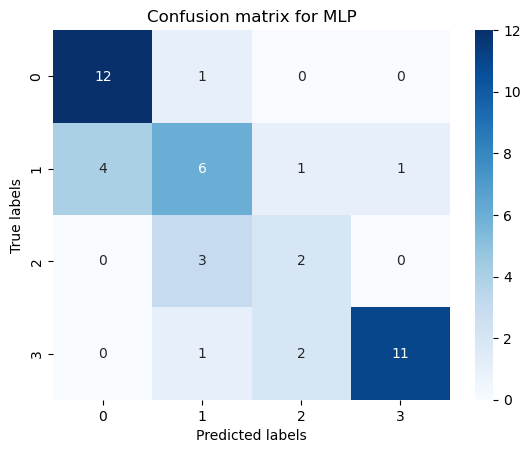

In [11]:
#split data
X_Train,X_Test,y_Train,y_Test = train_test_split(X, Y, test_size=0.2, random_state=42)

#validation vars
kf = KFold(n_splits=4, shuffle=True, random_state=42)
learning_rates = [0.0001, 0.0005,0.001,0.005, 0.01,0.05, 0.1,0.5, 1, 10]

#mlp vars
input_Size = X_Train.shape[1]
hidden_Sizes = [32,64,32,16]
output_Size = 4

#MLP functions
best_Lr = train_MLP(X_Train, y_Train, kf, learning_rates, input_Size, hidden_Sizes, output_Size) #to find best learning rate
best_Model = reTrain_MLP(X_Train, y_Train, best_Lr, input_Size, hidden_Sizes, output_Size) #to train on full training 
test_MLP(X_Test, y_Test, best_Model)



## Task 4:

In [12]:
#adapted code given on canvas announcment
def preprocess_Data(data, input_Window_Size=10, output_Window_Size=5, indicator_Columns=None):
    #sort data ascending by county and date
    sorted_data = data.sort_values(by=['country','date'], ascending=[True,True]).reset_index(drop=True)

    #create x, y sequences with windowing
    X, y = [],[]
    unique_countries = sorted_data['country'].unique()

    for country in unique_countries:
        country_Data = sorted_data[sorted_data['country'] == country].reset_index(drop=True)
        num_rows = len(country_Data)

        for start_idx in range(num_rows - input_Window_Size - output_Window_Size + 1):
            #get 10 year input window
            window = country_Data.iloc[start_idx:start_idx + input_Window_Size]
            input_Values = window[indicator_Columns].values.flatten()
            
            #get next 5 year gdp window
            output_Window = country_Data.iloc[start_idx + input_Window_Size:start_idx + input_Window_Size + output_Window_Size]
            output_Values = output_Window['GDPpc_2017$'].values

            X.append(input_Values)
            y.append(output_Values)

    #split data into training and testing sets
    train_Size = int(len(X) * 0.8)
    X_Train, y_Train = X[:train_Size], y[:train_Size]
    X_Test, y_Test = X[train_Size:], y[train_Size:]

    return X_Train, y_Train, X_Test, y_Test

def forecast_Data(data, input_Window_Size=10, indicator_Columns=None):
    #sort data to be ascending by date
    sorted_data = data.sort_values(by=['country','date'], ascending=[True,True]).reset_index(drop=True)

    #create x, y sequences with windowing
    X = []
    unique_countries = sorted_data['country'].unique()

    for country in unique_countries:
        country_Data = sorted_data[sorted_data['country'] == country].reset_index(drop=True)
        window = country_Data.iloc[-input_Window_Size:]
        input_Values = window[indicator_Columns].values.flatten()
        X.append(input_Values)

    return X

#create time series dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

#all indicator columns
indicator_Columns = [
 "GDPpc_2017$","Population_total","Life_exectancy","Literacy_rate","Unemploymlent_rate","Energy_use","Fertility_rate", "Poverty_ratio","Primary_school_enrolmet_rate","Exports_2017$"
]

X_Pred = forecast_Data(data,indicator_Columns=indicator_Columns)
X_Train, y_Train, X_Test, y_Test = preprocess_Data(data,indicator_Columns=indicator_Columns)

#reshape arrays from flat to 2d
X_Train = [x.reshape(10,10) for x in X_Train]
X_Test = [x.reshape(10,10) for x in X_Test]
X_Pred = [x.reshape(10,10) for x in X_Pred]
X_Pred_Tensor = torch.tensor(X_Pred, dtype=torch.float32)
#create DataLoader
batch_size = 32
train_Dataset = TimeSeriesDataset(X_Train, y_Train)
test_Dataset = TimeSeriesDataset(X_Test, y_Test)
pred_Dataset = TimeSeriesDataset(X_Pred, 0)
train_Loader = DataLoader(train_Dataset, batch_size=batch_size, shuffle=True)
test_Loader = DataLoader(test_Dataset, batch_size=batch_size, shuffle=False)
pred_Loader = DataLoader(pred_Dataset, batch_size=batch_size, shuffle=False)

In [13]:
#model training function
def train_model(model, train_Loader, optimizer, criterion, iters=500):
    for i in range(iters):
        #set the model to training mode
        model.train()
        train_Loss = 0
        for X_batch, y_batch in train_Loader:
            optimizer.zero_grad()
            outputs = model(X_batch)

            loss = criterion(outputs.squeeze(), y_batch)
            loss.backward()
            optimizer.step()
            train_Loss += loss.item()
        if i%10 == 0:
            print(f"Iter {i+1}, Loss: {train_Loss / len(train_Loader)}")
            
criterion = MAPELoss()

In [14]:
#LSTM vars
input_size = 10
hidden_size = 64
num_layers = 2
output_size = 5

#LSTM training
lstm_Model = LSTMModel(input_size, hidden_size, num_layers, output_size)
optimizer = torch.optim.Adam(lstm_Model.parameters(), lr=0.001)
train_model(lstm_Model, train_Loader, optimizer, criterion, iters = 101)

Iter 1, Loss: 36.18370546861129
Iter 11, Loss: 8.480887057564475
Iter 21, Loss: 6.381354960528287
Iter 31, Loss: 6.274055769949248
Iter 41, Loss: 6.224620326360067
Iter 51, Loss: 6.106642841570305
Iter 61, Loss: 5.848248717279145
Iter 71, Loss: 5.543032227140484
Iter 81, Loss: 5.285233815511067
Iter 91, Loss: 5.361419729752974
Iter 101, Loss: 5.520678156072443


In [ ]:
#CNN-LSTM vars
input_dim = 10
cnn_out_channels = 64
lstm_hidden_dim = 128
output_dim = 5
kernel_size = 3
n_layers = 2

#CNN-LSTM training
CNN_LSTM_Model = CNNLSTMModel(input_dim, cnn_out_channels, lstm_hidden_dim, output_dim, kernel_size, n_layers)
optimizer = torch.optim.Adam(CNN_LSTM_Model.parameters(), lr=0.001)
train_model(CNN_LSTM_Model, train_Loader, optimizer, criterion, iters = 101)

Iter 1, Loss: 32.48256214604233
Iter 11, Loss: 8.521478297493674
Iter 21, Loss: 7.188618168686375
Iter 31, Loss: 6.884279294447466
Iter 41, Loss: 6.559022266214544
Iter 51, Loss: 6.539344682115497
Iter 61, Loss: 5.940503061178958
Iter 71, Loss: 6.196138994621508


In [ ]:
#transformer
"""
batch_size = 32
train_Dataset = TimeSeriesDataset(X_Train, y_Train)
test_Dataset = TimeSeriesDataset(X_Test, y_Test)
train_Loader = DataLoader(train_Dataset, batch_size=batch_size, shuffle=True)
test_Loader = DataLoader(test_Dataset, batch_size=batch_size, shuffle=False)
"""
feature_size = 10
num_heads = 2
transformer_hidden_dim = 2
output_dim = 5

Transformer_Model = TransformerModel(feature_size,num_heads,transformer_hidden_dim,output_dim) 
optimizer = torch.optim.AdamW(Transformer_Model.parameters(), lr=0.001)
train_model(Transformer_Model, train_Loader, optimizer, criterion, iters = 51)

In [ ]:
def model_predict(model, pred):
    model.eval()
    with torch.no_grad():
        Y_Pred = model(pred)
        Y_Pred = Y_Pred.cpu().numpy()
        #print(type(Y_Pred))
        #print(Y_Pred.shape)
    return Y_Pred

def pred_plot(pred, model_name):
    #get country predicted data indices
    country_Indicies = {
        "Brazil": 26,
        "China" : 41,
        "Russian Federation" : 162,
        "United States" : 208
    }

    fig, axes =plt.subplots(2,2, figsize=(12,10))
    axes = axes.flatten()

    for i, (country, index) in enumerate(country_Indicies.items()):
        country_data = countries.get_country_data(country).get_df()
        
        X_min = scaler.data_min_[0]
        X_max = scaler.data_max_[0]

        country_pred = pred[index,:]
        country_pred = country_pred * (X_max - X_min) + X_min
        
        print(country_pred)

        #get country gdp data
        country_gdp = country_data["GDPpc_2017$"].values
        country_gdp = np.flip(country_gdp)
        country_gdp = country_gdp * (X_max - X_min) + X_min
        
        #get year values
        years = np.array(np.flip(country_data["date"].dt.year))

        #last 10 years of actual data
        last_10_Years = years[-10:]
        last_10_gdp = country_gdp[-10:]
        
        #add 5 years to years list
        last_year = last_10_Years[-1]
        pred_Years = np.arange(last_year + 1, last_year + 6)
        full_years = np.concatenate((last_10_Years, pred_Years))
        full_gdp = np.concatenate((last_10_gdp, [last_10_gdp[-1]], country_pred))
        
        #plot last ten years
        ax = axes[i]
        ax.plot(last_10_Years, last_10_gdp, label=f"{country} last 10 Years", color="blue", linestyle='-')

        #plot 5 year forecast
        ax.plot(full_years[-6:], full_gdp[-6:], label=f"{country} 5 year forecast", color="red", linestyle='--')

        ax.set_xlabel("Years")
        ax.set_ylabel("GDP per capita (2017$)")
        ax.set_title(f"{country} forecast")
        ax.legend()
    fig.suptitle(f"{model_name} predicitions")
    plt.tight_layout()
    plt.show()

Y_Pred_LSTM = model_predict(lstm_Model, X_Pred_Tensor)
Y_Pred_CNN_LSTM = model_predict(CNN_LSTM_Model, X_Pred_Tensor)
Y_Pred_Transformer = model_predict(Transformer_Model, X_Pred_Tensor)
pred_plot(Y_Pred_LSTM, "LSTM")
pred_plot(Y_Pred_CNN_LSTM, "CNN-LSTM")
pred_plot(Y_Pred_Transformer, "Transformer")
    